[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EQuS/jaxquantum/blob/main/docs/documentation/tutorials/sparse_backends.ipynb)

In [1]:
# !pip install git+https://github.com/EQuS/jaxquantum.git  # Uncomment when running in Colab.

# Sparse Backends

*This is an executable IPython Notebook tutorial.*

jaxquantum supports three storage backends for quantum operators and states:

| Backend | `implementation=` | Memory | Best for |
|---|---|---|---|
| **Dense** | `"dense"` (default) | $O(N^2)$ | Small Hilbert spaces, general use |
| **SparseDIA** | `"sparse_dia"` | $O(d \cdot N)$ | Ladder operators ($\hat{a}$, $\hat{n}$, $\hat{n}^2$) |
| **BCOO** | `"sparse_bcoo"` | $O(\mathrm{nnz})$ | Arbitrary sparse operators |

**When to choose which:**
- Use **SparseDIA** for operators with a fixed diagonal structure — annihilation ($\hat{a}$), creation ($\hat{a}^\dagger$), number ($\hat{n}$), Kerr ($\hat{n}^2$). All offsets are known at compile time, so there is *zero* index overhead.
- Use **BCOO** for operators that are sparse but have no regular diagonal structure (e.g. tight-binding models, custom Lindbladians).
- All three backends share the same operator API — switching is one argument.

This tutorial covers:

1. **SparseDIA basics** — diagonal structure, arithmetic, `powm()`
2. **BCOO basics** — arbitrary sparse operators, native operations
3. **Decaying oscillator** — single `mesolve` run, both formats, analytic comparison
4. **Type promotion & conversions** — mixing backends
5. **Scaling to large Hilbert spaces** — memory and `sesolve` timing at $N = 400$

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import jaxquantum as jqt

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import time

jax.config.update("jax_enable_x64", True)

## 1. SparseDIA Basics

SparseDIA stores only the non-zero *diagonals* of a matrix: a compact `(n_diags, N)` array of values plus a static Python tuple of integer offsets. Because the offsets are Python metadata (not JAX arrays), JAX unrolls all diagonal loops at compile time — there is no dynamic indexing or scatter/gather overhead at runtime.

In [4]:
N = 10

a    = jqt.destroy(N,  implementation="sparse_dia")
adag = jqt.create(N,   implementation="sparse_dia")
n_op = jqt.num(N,      implementation="sparse_dia")
eye  = jqt.identity(N, implementation="sparse_dia")

print("a is sparse_dia: ", a.is_sparse_dia)

# Each operator stores only its non-zero diagonal
print("destroy offsets: ", a._impl._offsets)     # (1,)  — one super-diagonal
print("num     offsets: ", n_op._impl._offsets)  # (0,)  — main diagonal only
print("create  offsets: ", adag._impl._offsets)  # (-1,) — one sub-diagonal

a is sparse_dia:  True
destroy offsets:  (1,)
num     offsets:  (0,)
create  offsets:  (-1,)


In [5]:
# Arithmetic stays SparseDIA — offsets are merged at compile time
X_op = a + adag   # offsets (-1, 1)  — position quadrature
print("(a + a†) offsets:", X_op._impl._offsets)

# n² (Kerr anharmonicity) via powm() — binary exponentiation, stays SparseDIA
n_sq = n_op.powm(2)
print("n² offsets:      ", n_sq._impl._offsets)  # (0,) — still diagonal

# Build a Kerr Hamiltonian: H = ωn̂ - (K/2) n̂(n̂-1)
omega, K = 1.0, 0.05
H_kerr = omega * n_op - (K / 2) * n_op.powm(2) + (K / 2) * n_op
print("H_kerr offsets:  ", H_kerr._impl._offsets)  # (0,) — purely diagonal

# Verify against analytic eigenvalues E_n = ω*n - (K/2)*n*(n-1)
ns = jnp.arange(N)
E_analytic = omega * ns - (K / 2) * ns * (ns - 1)
print("Analytic E_n[:4]:", E_analytic[:4])
print("Stored diag [:4]: ", H_kerr._impl._diags[0, :4].real)

(a + a†) offsets: (-1, 1)
n² offsets:       (0,)


H_kerr offsets:   (0,)
Analytic E_n[:4]: [0.   1.   1.95 2.85]


Stored diag [:4]:  [0.   1.   1.95 2.85]


## 2. BCOO Basics

BCOO (Batch COOrdinate) stores general sparse matrices as `(row, col, value)` triplets. It handles operators that have no regular diagonal structure — while sharing the same Qarray API as SparseDIA and dense.

In [6]:
a_bcoo    = jqt.destroy(N,  implementation="sparse_bcoo")
adag_bcoo = jqt.create(N,   implementation="sparse_bcoo")
n_bcoo    = jqt.num(N,      implementation="sparse_bcoo")

print("a is sparse_bcoo:", a_bcoo.is_sparse_bcoo)

# Arithmetic stays BCOO
adag_a_bcoo = adag_bcoo @ a_bcoo
print("adag @ a is sparse_bcoo:", adag_a_bcoo.is_sparse_bcoo)
print("tr(a†a)  =", float(jnp.real(jqt.tr(adag_a_bcoo))),  "(expected", N*(N-1)//2, ")")

# Density matrix stays sparse
ket3 = jqt.basis(N, 3, implementation="sparse_bcoo")
rho3 = jqt.ket2dm(ket3)
print("ket2dm stays sparse:", rho3.is_sparse_bcoo)
print("norm(ρ₃)  =", float(jnp.real(jqt.norm(rho3))))

a is sparse_bcoo: True


adag @ a is sparse_bcoo: True
tr(a†a)  = 45.0 (expected 45 )


ket2dm stays sparse: True
norm(ρ₃)  = 1.0


**SparseDIA vs BCOO at a glance:**

| | SparseDIA | BCOO |
|---|---|---|
| Index overhead | None (offsets are Python metadata) | `(row, col)` stored per nonzero |
| Matmul cost | $O(d \cdot N)$ aligned slice ops | Scatter/gather over nnz entries |
| Supports arbitrary sparsity | No (diagonals only) | Yes |
| Best for | $\hat{a}$, $\hat{n}$, $\hat{n}^2$ | Charge-basis Hamiltonians, custom ops |

## 3. Decaying Harmonic Oscillator

We simulate the same system with both backends and verify they agree with each other and with the analytic solution $\langle\hat{n}\rangle(t) = n_0 e^{-\kappa t}$.

Max |SparseDIA - BCOO|: 8.881784197001252e-16


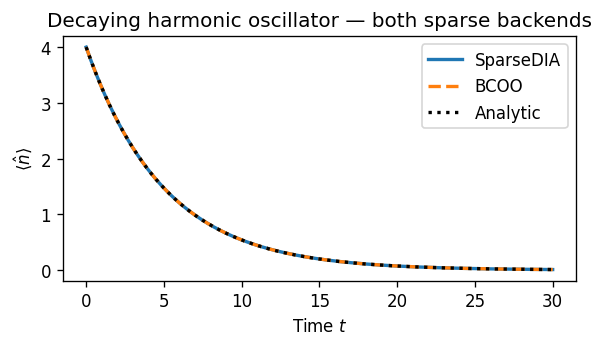

In [7]:
N, omega, kappa, n0 = 20, 1.0, 0.2, 4

rho0  = jqt.ket2dm(jqt.basis(N, n0))
tlist = jnp.linspace(0.0, 30.0, 300)

def run_mesolve(impl):
    H     = omega * jqt.num(N, implementation=impl)
    c_ops = jqt.Qarray.from_list([jnp.sqrt(kappa) * jqt.destroy(N, implementation=impl)])
    return jqt.mesolve(
        H, rho0, tlist,
        c_ops=c_ops,
        solver_options=jqt.SolverOptions.create(progress_meter=False),
    )

result_dia  = run_mesolve("sparse_dia")
result_bcoo = run_mesolve("sparse_bcoo")

n_dia  = jnp.real(jqt.tr(jqt.num(N) @ result_dia))
n_bcoo = jnp.real(jqt.tr(jqt.num(N) @ result_bcoo))

# Both should match each other and the analytic solution
print("Max |SparseDIA - BCOO|:", float(jnp.max(jnp.abs(n_dia - n_bcoo))))

fig, ax = plt.subplots(figsize=(5, 3), dpi=120)
ax.plot(tlist, n_dia,                            label="SparseDIA", lw=2)
ax.plot(tlist, n_bcoo,  "--",                    label="BCOO",      lw=2)
ax.plot(tlist, n0 * jnp.exp(-kappa * tlist), ":", label="Analytic", lw=2, color="k")
ax.set_xlabel("Time $t$")
ax.set_ylabel(r"$\langle\hat{n}\rangle$")
ax.set_title("Decaying harmonic oscillator — both sparse backends")
ax.legend()
fig.tight_layout()

## 4. Type Promotion & Conversions

All three backends interoperate. Explicit conversion methods let you move between them; when mixed in arithmetic the higher-order type wins.

| Source → Target | Method |
|---|---|
| Any → Dense | `.to_dense()` |
| Any → SparseDIA | `.to_sparse_dia()` |
| Any → BCOO | `.to_sparse_bcoo()` |

**Promotion order:** SparseDIA (lowest) < BCOO < Dense (highest).  
SparseDIA + Dense → Dense; SparseDIA + BCOO → BCOO; BCOO + Dense → Dense.

In [8]:
a_dia   = jqt.destroy(N, implementation="sparse_dia")
a_bcoo  = jqt.destroy(N, implementation="sparse_bcoo")
a_dense = jqt.destroy(N)  # default: dense

# Explicit conversions
print("dia  → dense: ",     a_dia.to_dense().is_dense)
print("dia  → bcoo:  ",     a_dia.to_sparse_bcoo().is_sparse_bcoo)
print("dense → dia:  ",     a_dense.to_sparse_dia().is_sparse_dia)

# Round-trip
rt_correct = jnp.allclose(a_dia.to_dense().to_sparse_dia().to_dense().data, a_dia.to_dense().data)
print("Round-trip SparseDIA → dense → SparseDIA correct:", rt_correct)

# Type promotion in mixed arithmetic
print("SparseDIA + Dense  →", (a_dia   + a_dense).impl_type)
print("SparseDIA + BCOO   →", (a_dia   + a_bcoo ).impl_type)
print("BCOO      + Dense  →", (a_bcoo  + a_dense).impl_type)

dia  → dense:  True
dia  → bcoo:   True
dense → dia:   True
Round-trip SparseDIA → dense → SparseDIA correct: True
SparseDIA + Dense  → QarrayImplType.DENSE
SparseDIA + BCOO   → QarrayImplType.SPARSE_BCOO
BCOO      + Dense  → QarrayImplType.DENSE


## 5. Scaling to Large Hilbert Spaces

The real payoff from sparse formats comes at large $N$. In bosonic qubit simulations, Hilbert space dimensions of $N = 200$–$500$ are common (GKP codes need $N \approx 60$–$100$; large cat states need $N \approx 200$–$500$).

For `sesolve` (state-vector evolution, $|\psi\rangle \in \mathbb{C}^N$), the ODE right-hand side is $-iH|\psi\rangle$:
- **Dense** $H$: $O(N^2)$ multiply-add per step.
- **SparseDIA** $H = \omega\hat{n}$: $O(N)$ per step — just scale each element by the diagonal value.

The memory picture is equally stark: `destroy(N=400)` with SparseDIA stores **400 values** vs **160,000** for dense.

In [9]:
N_large = 400

# Memory: SparseDIA stores d*N values; dense stores N²
a_dia_large   = jqt.destroy(N_large, implementation="sparse_dia")
a_dense_large = jqt.destroy(N_large)

n_dia_vals   = a_dia_large._impl._diags.size
n_dense_vals = N_large ** 2
print(f"destroy(N={N_large})")
print(f"  Dense:    {n_dense_vals:,} stored values")
print(f"  SparseDIA: {n_dia_vals:,} stored values  ({n_dense_vals // n_dia_vals}× reduction)")

destroy(N=400)
  Dense:    160,000 stored values
  SparseDIA: 400 stored values  (400× reduction)


In [10]:
# Timing: sesolve for a coherent state |α⟩ evolving under H = ωn̂
# Analytic result: |α e^{-iωt}⟩ — coherent state rotates in phase space.
# This is a clean, verifiable example with no open-system complications.

N_t   = 400
omega = 1.0
alpha = 3.0
psi0  = jqt.displace(N_t, alpha) @ jqt.basis(N_t, 0)
tlist = jnp.linspace(0.0, 4 * jnp.pi, 200)  # two full oscillations

def run_sesolve(impl):
    H = omega * jqt.num(N_t, implementation=impl)
    return jqt.sesolve(H, psi0, tlist,
                       solver_options=jqt.SolverOptions.create(progress_meter=False))

# Warm-up JIT compilation
_ = run_sesolve("dense")
_ = run_sesolve("sparse_dia")

# Time dense
t0 = time.perf_counter()
result_dense = run_sesolve("dense")
result_dense.data.block_until_ready()
t_dense = time.perf_counter() - t0

# Time SparseDIA
t0 = time.perf_counter()
result_dia = run_sesolve("sparse_dia")
result_dia.data.block_until_ready()
t_dia = time.perf_counter() - t0

print(f"Dense     sesolve (N={N_t}): {t_dense*1000:.0f} ms")
print(f"SparseDIA sesolve (N={N_t}): {t_dia*1000:.0f} ms")
print(f"Speedup: {t_dense/t_dia:.1f}×")

# Verify: both should give |⟨n⟩| ≈ α² (coherent state photon number is constant)
n_op = jqt.num(N_t)
n_dense = jnp.real(jqt.tr(n_op @ jqt.ket2dm(result_dense)))
n_dia   = jnp.real(jqt.tr(n_op @ jqt.ket2dm(result_dia)))
print(f"\nMax |dense - SparseDIA| ⟨n⟩: {float(jnp.max(jnp.abs(n_dense - n_dia))):.2e}")

Dense     sesolve (N=400): 2126 ms
SparseDIA sesolve (N=400): 694 ms
Speedup: 3.1×



Max |dense - SparseDIA| ⟨n⟩: 0.00e+00


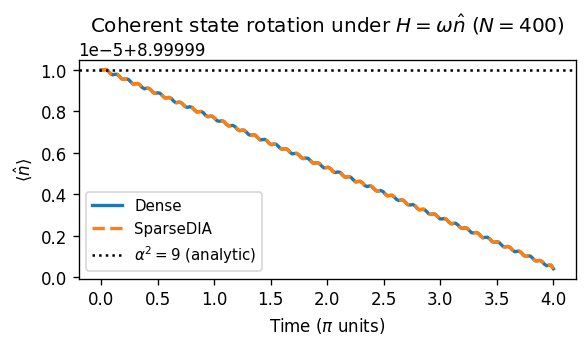

In [11]:
fig, ax = plt.subplots(figsize=(5, 3), dpi=120)
ax.plot(tlist / jnp.pi, n_dense, label="Dense",     lw=2)
ax.plot(tlist / jnp.pi, n_dia,   "--", label="SparseDIA", lw=2)
ax.axhline(alpha**2, color="k", ls=":", label=rf"$\alpha^2 = {alpha**2:.0f}$ (analytic)", lw=1.5)
ax.set_xlabel(r"Time ($\pi$ units)")
ax.set_ylabel(r"$\langle\hat{n}\rangle$")
ax.set_title(f"Coherent state rotation under $H = \\omega\\hat{{n}}$ ($N={N_t}$)")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## What's Next?

- Build device Hamiltonians from first principles: see [Devices & Systems](devices.html).
- Use sparse operators inside bosonic code simulations: see [Bosonic Codes](bosonic_codes.html).
- Combine sparse operators with gate-based circuits: see [Circuits](circuits.html).